<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data 
y = iris.target  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

import numpy as np
print(f"Proporções no treino: {np.bincount(y_train) / len(y_train)}")
print(f"Proporções no teste: {np.bincount(y_test) / len(y_test)}")

Proporções no treino: [0.33333333 0.33333333 0.33333333]
Proporções no teste: [0.33333333 0.33333333 0.33333333]


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(random_state=42)

clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Acurácia no treino: {train_accuracy:.4f}")
print(f"Acurácia no teste: {test_accuracy:.4f}")

Acurácia no treino: 1.0000
Acurácia no teste: 0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

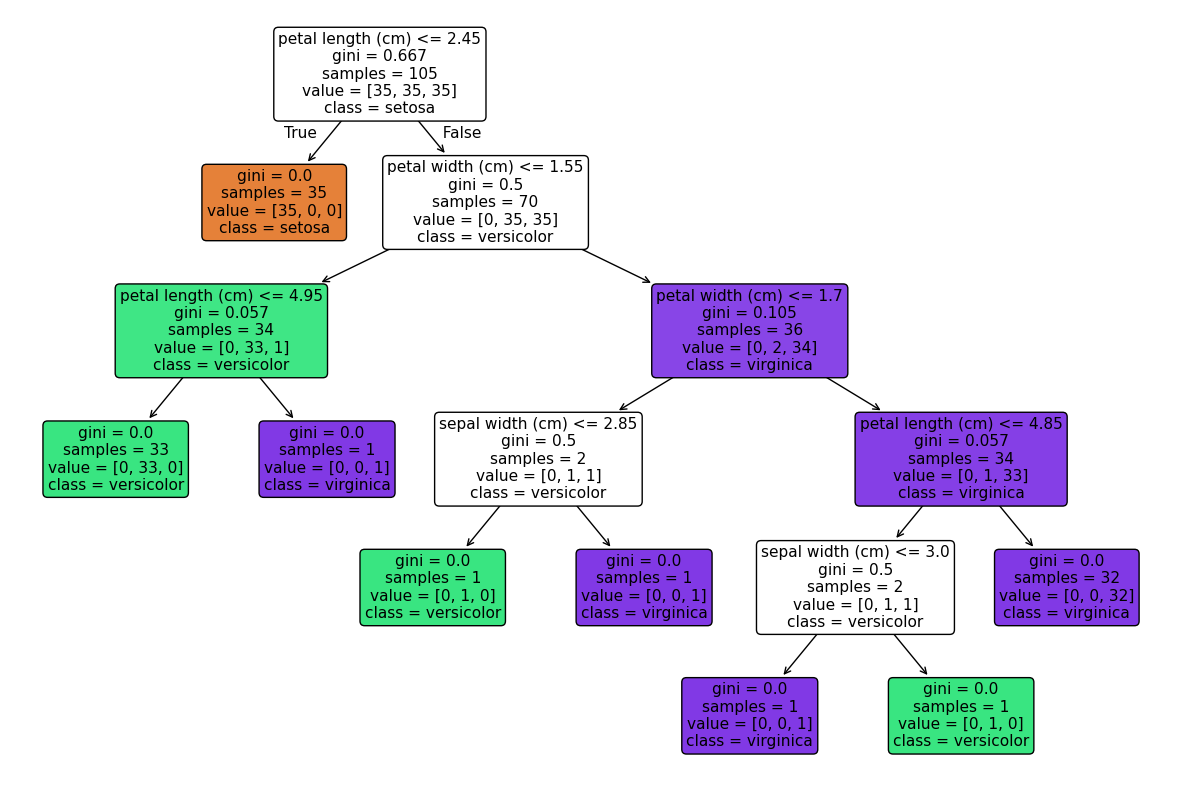

In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(clf, 
          feature_names=iris.feature_names, 
          class_names=iris.target_names, 
          filled=True, 
          rounded=True)

plt.show()

1) Qual atributo aparece na raiz?
O atributo que aparece no topo (raiz) é o "petal length (cm)". Porque em árvores de decisão, o atributo com maior ganho de informação é escolhido para a primeira divisão.

2) Qual é a profundidade da árvore?
A profundidade da árvore é 5.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]
results = []

for d in depths:
    clf_temp = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf_temp.fit(X_train, y_train)
    y_train_pred = clf_temp.predict(X_train)
    y_test_pred = clf_temp.predict(X_test)
    
    results.append({
        "Configuração (max_depth)": "Sem limite" if d is None else d,
        "Profundidade Real": clf_temp.get_depth(),
        "Nº de Folhas": clf_temp.get_n_leaves(),
        "Acurácia Treino": f"{accuracy_score(y_train, y_train_pred):.4f}",
        "Acurácia Teste": f"{accuracy_score(y_test, y_test_pred):.4f}"
    })

df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False))

| Configuração (max_depth)   |   Profundidade Real |   Nº de Folhas |   Acurácia Treino |   Acurácia Teste |
|:---------------------------|--------------------:|---------------:|------------------:|-----------------:|
| 1                          |                   1 |              2 |            0.6667 |           0.6667 |
| 2                          |                   2 |              3 |            0.9714 |           0.8889 |
| 3                          |                   3 |              5 |            0.981  |           0.9778 |
| 4                          |                   4 |              7 |            0.9905 |           0.8889 |
| 5                          |                   5 |              8 |            1      |           0.9333 |
| 6                          |                   5 |              8 |            1      |           0.9333 |
| 7                          |                   5 |              8 |            1      |           0.9333 |
| 8                

**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

Começa na configuração 6, onde a profundidade real, número de folhas, acurário treino e acurária de teste continuam iguais.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

criterios = ["gini", "entropy"]
resultados_comp = []

for crit in criterios:
    clf_comp = DecisionTreeClassifier(criterion=crit, random_state=42)
    clf_comp.fit(X_train, y_train)
    
    y_test_pred = clf_comp.predict(X_test)
    
    resultados_comp.append({
        "Critério": crit.capitalize(),
        "Profundidade": clf_comp.get_depth(),
        "Acurácia Teste": f"{accuracy_score(y_test, y_test_pred):.4f}"
    })

import pandas as pd
df_comp = pd.DataFrame(resultados_comp)
print(df_comp.to_markdown(index=False))

| Critério   |   Profundidade |   Acurácia Teste |
|:-----------|---------------:|-----------------:|
| Gini       |              5 |           0.9333 |
| Entropy    |              6 |           0.8889 |


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

leaf_values = range(1, 21)
results_leaf = []

for leaf in leaf_values:
    clf_leaf = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    clf_leaf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf_leaf.predict(X_train))
    test_acc = accuracy_score(y_test, clf_leaf.predict(X_test))
    results_leaf.append({
        "min_samples_leaf": leaf,
        "Acurácia Treino": train_acc,
        "Acurácia Teste": test_acc,
        "Profundidade": clf_leaf.get_depth()
    })

df_leaf = pd.DataFrame(results_leaf)
melhor_modelo = df_leaf.sort_values(by="Acurácia Teste", ascending=False).iloc[0]
print(df_leaf.to_markdown(index=False))

|   min_samples_leaf |   Acurácia Treino |   Acurácia Teste |   Profundidade |
|-------------------:|------------------:|-----------------:|---------------:|
|                  1 |          1        |         0.933333 |              5 |
|                  2 |          0.971429 |         0.888889 |              4 |
|                  3 |          0.980952 |         0.844444 |              4 |
|                  4 |          0.971429 |         0.888889 |              4 |
|                  5 |          0.971429 |         0.888889 |              3 |
|                  6 |          0.971429 |         0.888889 |              3 |
|                  7 |          0.971429 |         0.888889 |              3 |
|                  8 |          0.971429 |         0.888889 |              3 |
|                  9 |          0.971429 |         0.888889 |              3 |
|                 10 |          0.971429 |         0.888889 |              3 |
|                 11 |          0.971429 |         0